In [ ]:
from google.colab import files
uploaded = files.upload()

Saving stock_data.csv to stock_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("stock_data.csv")

df.isnull().sum()

,0
Date,0
AAPL,0
AMZN,0
GOOGL,0
MSFT,0
TSLA,0


In [ ]:
print(df.columns)

Index(['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA'], dtype='object')


In [ ]:
print(df.head())

                 AAPL       AMZN      GOOGL        MSFT       TSLA
Date                                                              
2020-01-02  72.400520  94.900497  67.873032  152.158371  28.684000
2020-01-03  71.696655  93.748497  67.517975  150.263718  29.534000
2020-01-06  72.267937  95.143997  69.317589  150.652161  30.102667
2020-01-07  71.928062  95.343002  69.183693  149.278564  31.270666
2020-01-08  73.085106  94.598503  69.676132  151.656296  32.809334


In [ ]:
df.index = pd.to_datetime(df.index)

In [ ]:
import pandas as pd

df = pd.read_csv("stock_data.csv", index_col=0)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

print(df.head())

                 AAPL       AMZN      GOOGL        MSFT       TSLA
Date                                                              
2020-01-02  72.400520  94.900497  67.873032  152.158371  28.684000
2020-01-03  71.696655  93.748497  67.517975  150.263718  29.534000
2020-01-06  72.267937  95.143997  69.317589  150.652161  30.102667
2020-01-07  71.928062  95.343002  69.183693  149.278564  31.270666
2020-01-08  73.085106  94.598503  69.676132  151.656296  32.809334


In [ ]:
# Daily Log Returns Calculation
import numpy as np

log_returns = np.log(df / df.shift(1))
log_returns.dropna(inplace=True)

print(log_returns.head())

                AAPL      AMZN     GOOGL      MSFT      TSLA
Date                                                        
2020-01-03 -0.009769 -0.012213 -0.005245 -0.012530  0.029203
2020-01-06  0.007936  0.014776  0.026305  0.002582  0.019072
2020-01-07 -0.004714  0.002089 -0.001933 -0.009159  0.038067
2020-01-08  0.015958 -0.007839  0.007093  0.015803  0.048033
2020-01-09  0.021018  0.004788  0.010443  0.012416 -0.022189


In [ ]:
#Value at Risk (VaR) – 95% Confidence
import numpy as np

# Portfolio returns (mean of all stocks)
portfolio_returns = log_returns.mean(axis=1)

# Mean and std
mean = portfolio_returns.mean()
std = portfolio_returns.std()

# VaR at 95%
VaR_95 = mean - 1.65 * std

print("Value at Risk (95%):", VaR_95)

Value at Risk (95%): -0.031958519596390164


In [ ]:
#Volatility Analysis
#Historical Volatility
volatility = log_returns.std()
print(volatility)

AAPL     0.019940
AMZN     0.022652
GOOGL    0.020488
MSFT     0.019228
TSLA     0.042205
dtype: float64


<Axes: title={'center': 'Rolling Volatility'}, xlabel='Date'>

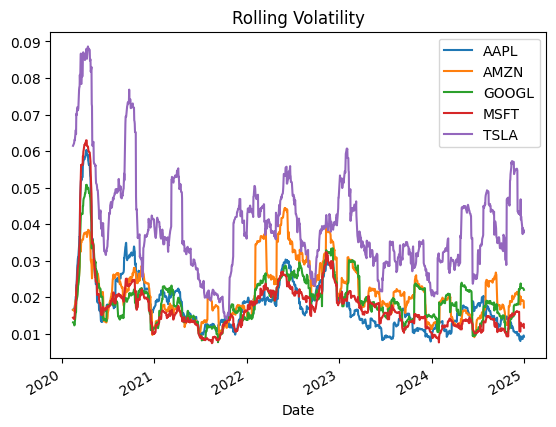

In [ ]:
#Rolling Volatility
rolling_vol = log_returns.rolling(window=30).std()

rolling_vol.plot(title="Rolling Volatility")

In [ ]:
import numpy as np
import pandas as pd

# Step 1: Calculate log returns
log_returns = np.log(df / df.shift(1))
log_returns.dropna(inplace=True)

# Step 2: Portfolio returns (average)
portfolio_returns = log_returns.mean(axis=1)

# Step 3: Mean and Std
mean = portfolio_returns.mean()
std = portfolio_returns.std()

# Step 4: Monte Carlo Simulation
num_simulations = 1000
time_horizon = 252   # 1 year (trading days)

simulated_returns = np.random.normal(mean, std, (time_horizon, num_simulations))

# Step 5: Convert to price paths
initial_value = 100
price_paths = initial_value * np.exp(np.cumsum(simulated_returns, axis=0))

# Step 6: Final portfolio values
final_values = price_paths[-1]

# Step 7: Calculate VaR (95%)
VaR_95 = np.percentile(final_values, 5)

print("Monte Carlo VaR (95%):", VaR_95)

Monte Carlo VaR (95%): 76.7096050515121


In [ ]:
VaR_loss = initial_value - VaR_95
print("VaR Loss:", VaR_loss)

VaR Loss: 23.2903949484879


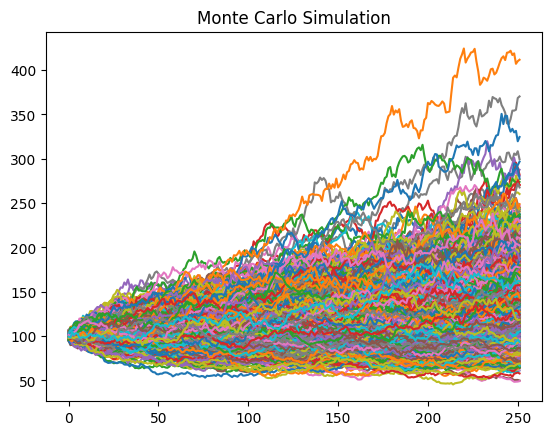

In [ ]:
import matplotlib.pyplot as plt

plt.plot(price_paths)
plt.title("Monte Carlo Simulation")
plt.show()

In [ ]:
from google.colab import files
df.to_csv("portfolio_data.csv")
files.download("portfolio_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd

# Re-upload the file if stock_data.csv is not found (e.g., if runtime restarted)
try:
    df = pd.read_csv("stock_data.csv", index_col=0)
except FileNotFoundError:
    print("stock_data.csv not found. Please upload the file.")
    uploaded = files.upload()
    df = pd.read_csv("stock_data.csv", index_col=0)

# Convert index to datetime
df.index = pd.to_datetime(df.index)

returns = df.pct_change().dropna() # Added dropna to handle first row NaN

# Save to a Colab-accessible path and provide download link
returns.to_csv("returns_data.csv")
files.download("returns_data.csv")

stock_data.csv not found. Please upload the file.


Saving stock_data.csv to stock_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Correlation matrix
correlation = log_returns.corr()

print(correlation)

           AAPL      AMZN     GOOGL      MSFT      TSLA
AAPL   1.000000  0.594780  0.652854  0.750913  0.492477
AMZN   0.594780  1.000000  0.649973  0.680171  0.436566
GOOGL  0.652854  0.649973  1.000000  0.747925  0.406230
MSFT   0.750913  0.680171  0.747925  1.000000  0.456088
TSLA   0.492477  0.436566  0.406230  0.456088  1.000000


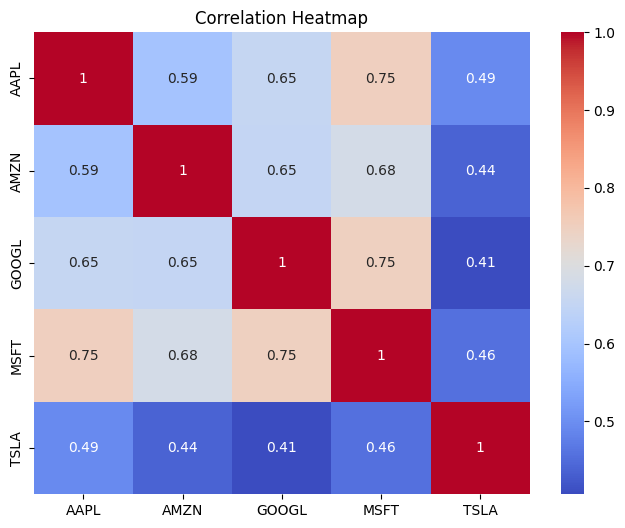

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
correlation.to_csv("correlation_data.csv")

from google.colab import files
files.download("correlation_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>